In [5]:
# Importieren der benötigten Bibliotheken
import pandas as pd
import numpy as np

# Laden der CSV-Datei in einen DataFrame
df = pd.read_csv('../data/interim/verkaufe_clean.csv')

# Anzeigen der grundlegenden Informationen über den Datensatz
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14400 entries, 0 to 14399
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   produkt_id                      14400 non-null  object 
 1   kategorie                       14400 non-null  object 
 2   hersteller                      14400 non-null  object 
 3   monat                           14400 non-null  object 
 4   jahr                            14400 non-null  int64  
 5   monat_idx                       14400 non-null  int64  
 6   preis_eur                       14400 non-null  float64
 7   wettbewerber_preis_eur          14400 non-null  float64
 8   marketingbudget_eur             14400 non-null  float64
 9   marketingbudget_geschaetzt      14400 non-null  int64  
 10  kampagne_aktiv                  14400 non-null  int64  
 11  lagerbestand                    14400 non-null  int64  
 12  bewertungen_durchschnitt        

In [7]:
# Konvertiert die Spalte 'monat' in das korrekte Datetime-Format,
# da Pandas beim Importieren standardmäßig Datumsangaben als Text (Object) einliest
df['monat'] = pd.to_datetime(df['monat'])

In [8]:
# Zeigt die wichtigsten statistischen Kennzahlen des Datensatzes an
df.describe()

,monat,jahr,monat_idx,preis_eur,wettbewerber_preis_eur,marketingbudget_eur,marketingbudget_geschaetzt,kampagne_aktiv,lagerbestand,bewertungen_durchschnitt,bewertungen_ergaenzt,bewertungen_anzahl,vormonat_umsatz_eur,neues_produkt,letzte_3_monate_umsatz_eur_avg,hat_3_monats_durchschnitt,vorjahr_monat_umsatz_eur,hat_vorjahreswert,umsatz_eur,umsatz_korrigiert
count,14400,14400.000000,14400.000000,14400.000000,14400.000000,14400.000000,14400.000000,14400.000000,14400.000000,14400.000000,14400.000000,14400.000000,13800.000000,14400.000000,12600.000000,14400.00000,7200.000000,14400.000000,14400.000000,14400.000000
mean,2024-12-15 22:00:00,2024.500000,6.500000,26.176350,26.168160,89.654606,0.030000,0.113264,74.404722,3.508500,0.040000,40.203333,526.697704,0.041667,546.350723,0.87500,515.008771,0.500000,517.326726,0.000347
min,2024-01-01 00:00:00,2024.000000,1.000000,1.500000,1.280000,0.000000,0.000000,0.000000,1.000000,1.500000,0.000000,24.000000,1.710000,0.000000,2.293333,0.00000,1.820000,0.000000,1.630000,0.000000
25%,2024-06-23 12:00:00,2024.000000,3.750000,8.127500,8.010000,69.677500,0.000000,0.000000,42.000000,3.000000,0.000000,36.000000,71.607500,0.000000,78.705000,1.00000,69.290000,0.000000,70.185000,0.000000
50%,2024-12-16 12:00:00,2024.500000,6.500000,20.635000,20.330000,88.080000,0.000000,0.000000,66.000000,3.500000,0.000000,40.000000,207.490000,0.000000,225.015000,1.00000,204.810000,0.500000,202.820000,0.000000
75%,2025-06-08 12:00:00,2025.000000,9.250000,34.662500,34.852500,108.027500,0.000000,0.000000,97.000000,4.000000,0.000000,44.000000,579.292500,0.000000,622.240000,1.00000,566.207500,1.000000,568.000000,0.000000
max,2025-12-01 00:00:00,2025.000000,12.000000,143.500000,164.700000,236.790000,1.000000,1.000000,441.000000,5.000000,1.000000,59.000000,20617.850000,1.000000,16162.513333,1.00000,20617.850000,1.000000,20617.850000,1.000000
std,NaN,0.500017,3.452172,23.304888,23.519691,29.644290,0.170593,0.316926,43.545396,0.687709,0.195966,6.091078,962.874629,0.199833,942.684993,0.33073,941.702438,0.500017,949.379139,0.018631


# 1.1 Analyse der Umsatzverteilung nach Kategorien

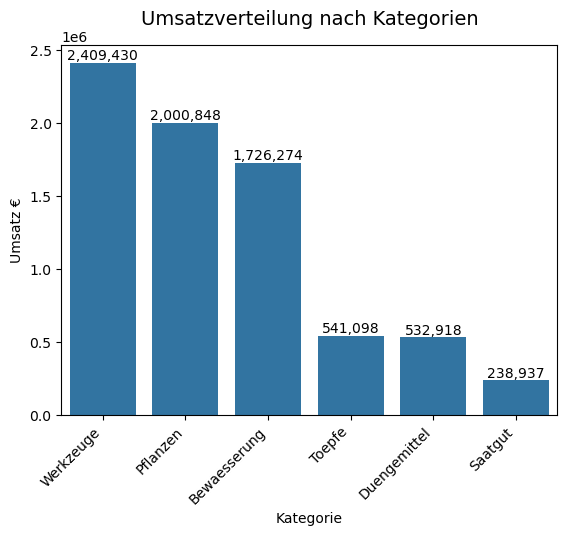

In [23]:
# Importieren der Bibliotheken für die Datenvisualisierung
import matplotlib.pyplot as plt
import seaborn as sns

# Gruppieren des Umsatzes nach Produktkategorien
df_kategorien=df.groupby(['kategorie'])['umsatz_eur'].sum().reset_index().sort_values(by='umsatz_eur', ascending=False)

# Erstellen des Balkendiagramms
sns.barplot(data=df_kategorien, 
            x='kategorie', 
            y='umsatz_eur'
            )

# Hinzufügen von Werten auf den Balken (ohne Nachkommastellen und mit Tausendertrennzeichen)
plt.gca().bar_label(plt.gca().containers[0], fmt="{:,.0f}")
# Rotieren der X-Achsen-Beschriftungen um 45 Grad zur besseren Lesbarkeit
plt.xticks(rotation=45, ha='right')

# Beschriftung der X-Achse
plt.xlabel('Kategorie')  
# Beschriftung der Y-Achse
plt.ylabel('Umsatz €')  

# Festlegen des Diagrammtitels
plt.title('Umsatzverteilung nach Kategorien', fontsize=14, pad=15)
# Anzeigen des fertigen Diagramms
plt.show()

In [10]:
# Berechnet den Gesamtumsatz für den gesamten Zeitraum (2 Jahre)
df['umsatz_eur'].sum()

np.float64(7449504.85)

Aus der Grafik geht hervor, dass Werkzeuge, Pflanzen und Bewässerungssysteme mit über 82 % den Hauptanteil am Gesamtumsatz ausmachen.

# 1.2 Analyse der Umsatzverteilung Herstellern

In [11]:
# Zeigt die einzigartigen Hersteller im Datensatz an
df['hersteller'].unique()

array(['Hortica', 'GartenStern', 'BioGruen', 'Vivero', 'Floraplan',
       'Garda Tools'], dtype=object)

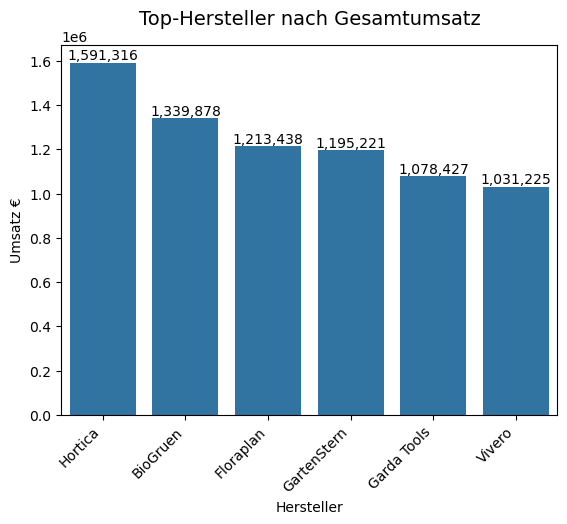

In [24]:
# Gruppiert den Umsatz nach Herstellern
df_hersteller=df.groupby(['hersteller'])['umsatz_eur'].sum().reset_index().sort_values(by='umsatz_eur', ascending=False)

sns.barplot(data=df_hersteller, 
            x='hersteller', 
            y='umsatz_eur'
            )

plt.gca().bar_label(plt.gca().containers[0], fmt='{:,.0f}')
plt.xticks(rotation=45, ha='right')

plt.xlabel('Hersteller')  
plt.ylabel('Umsatz €') 

plt.title('Top-Hersteller nach Gesamtumsatz', fontsize=14, pad=15)
plt.show()

Hortica nimmt mit über 21 % am Gesamtumsatz die Spitzenposition ein, wohingegen Vivero mit knapp 14 % den letzten Platz belegt.

# 1.3 Analyse der Umsatzverteilung nach Preislagen

In [13]:
# Zeigt die Preisverteilung an, um die Preise später in Preisspannen einzuteilen
df['preis_eur'].describe()

count    14400.000000
mean        26.176350
std         23.304888
min          1.500000
25%          8.127500
50%         20.635000
75%         34.662500
max        143.500000
Name: preis_eur, dtype: float64

Anhand der Preisverteilung im Datensatz empfiehlt es sich, drei Kategorien festzulegen: Basisprodukte (bis 10 €), Standardprodukte (10 € bis 35 €) und Premiumprodukte (ab 35 €).

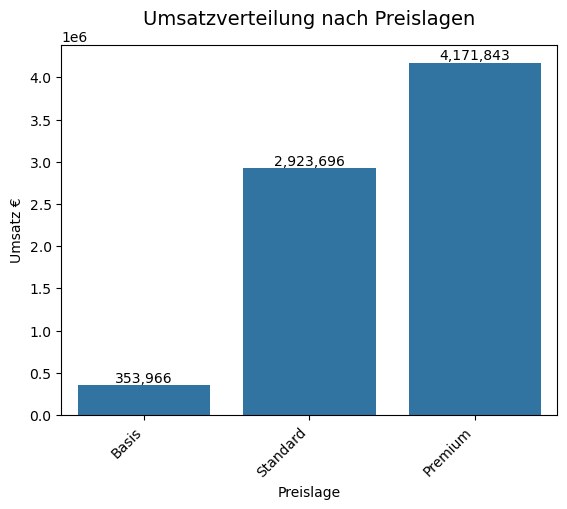

In [25]:
# Erstellt eine neue Spalte für die Preisklassen (Basis, Standard, Premium)
df['preislage'] = pd.cut(
    df['preis_eur'],
    bins=[0, 10, 35, float('inf')],
    labels=['Basis', 'Standard', 'Premium'],
)

# Gruppiert den Umsatz nach den neu erstellten Preisklassen
df_preislage=df.groupby(['preislage'], observed=False)['umsatz_eur'].sum().reset_index().sort_values(by='umsatz_eur', ascending=False)

# Visualisierung der Umsatzverteilung nach Preisklassen
sns.barplot(data=df_preislage, 
            x='preislage', 
            y='umsatz_eur'
            )

plt.gca().bar_label(plt.gca().containers[0], fmt='{:,.0f}')
plt.xticks(rotation=45, ha='right')

plt.xlabel('Preislage')  
plt.ylabel('Umsatz €') 

plt.title('Umsatzverteilung nach Preislagen', fontsize=14, pad=15)
plt.show()

Die Preisverteilung nach Kategorien verdeutlicht, dass das Premium-Segment mit 56 % des Gesamtumsatzes an der Spitze steht, gefolgt vom Standard-Segment mit einem Anteil von knapp 40 %.

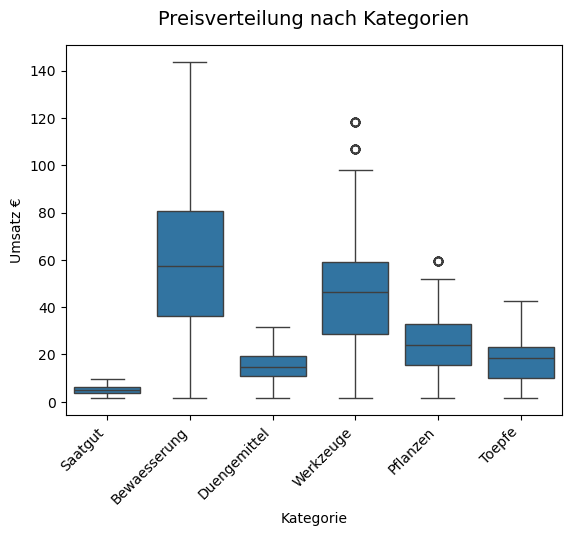

In [26]:
# Erstellt einen Boxplot zur Visualisierung der Preisverteilung pro Kategorie
sns.boxplot(data=df, 
            x='kategorie', 
            y='preis_eur'
            )

plt.xticks(rotation=45, ha='right')

plt.xlabel('Kategorie')  
plt.ylabel('Umsatz €')

plt.title('Preisverteilung nach Kategorien', fontsize=14, pad=15)
plt.show()

Die Auswertung verdeutlicht, dass Bewässerungssysteme und Werkzeuge als teuerste Kategorien die größte Preisspanne aufweisen. Im Gegensatz dazu bildet Saatgut die preiswerteste Gruppe mit geringer Streuung. Einzelne Ausreißer in Form untypisch teurer Artikel lassen sich bei Werkzeugen (2) und Pflanzen (1) beobachten.

Im nächsten Schritt betrachten wir die Verteilung der Hersteller nach Produktkategorien.

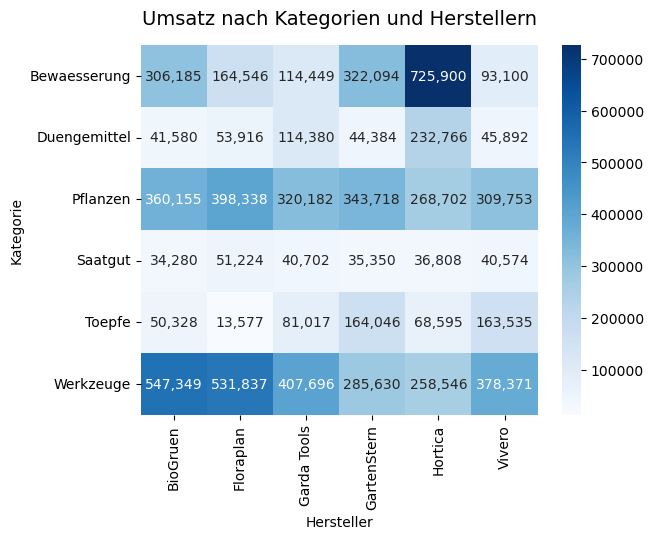

In [27]:
# Erstellt eine Pivot-Tabelle und eine Heatmap zur Analyse des Umsatzes nach Kategorien und Herstellern
df_pivot=df.pivot_table(index='kategorie',columns='hersteller',values='umsatz_eur',aggfunc='sum')

sns.heatmap(data=df_pivot, 
            annot=True, 
            fmt=',.0f',
            cmap='Blues'
            )

plt.xlabel('Hersteller')  
plt.ylabel('Kategorie')

plt.title('Umsatz nach Kategorien und Herstellern', fontsize=14, pad=15)
plt.show()

Die Heatmap zeigt, dass Hortica mit fast 10 % des Gesamtumsatzes im Bereich Bewässerung den herstellerübergreifend höchsten Einzelanteil generiert. Darüber hinaus leisten BioGruen (7,3 %) und Floraplan (7,1 %) in der Kategorie Werkzeuge einen wesentlichen Umsatzbeitrag.

### !!! Zusammenfassung: Umsatzstrukturen nach Kategorien, Herstellern und Preissegmenten

Der Umsatz verteilt sich vor allem auf wenige Bereiche:

* **Kategorien & Segmente:** Werkzeuge, Pflanzen und Bewässerungssysteme machen über 82 % des Gesamtumsatzes aus. Preislich liegen das Premium-Segment (ab 35 €) mit 56 % und das Standard-Segment mit knapp 40 % vorn.
* **Hersteller:** Hortica führt das Ranking mit über 21 % an und holt allein im Bereich Bewässerung knapp 10 %. Wichtige Umsätze bei Werkzeugen kommen außerdem von BioGruen (7,3 %) und Floraplan (7,1 %).

# 2.1 Saisonalität des Gesamtumsatzes

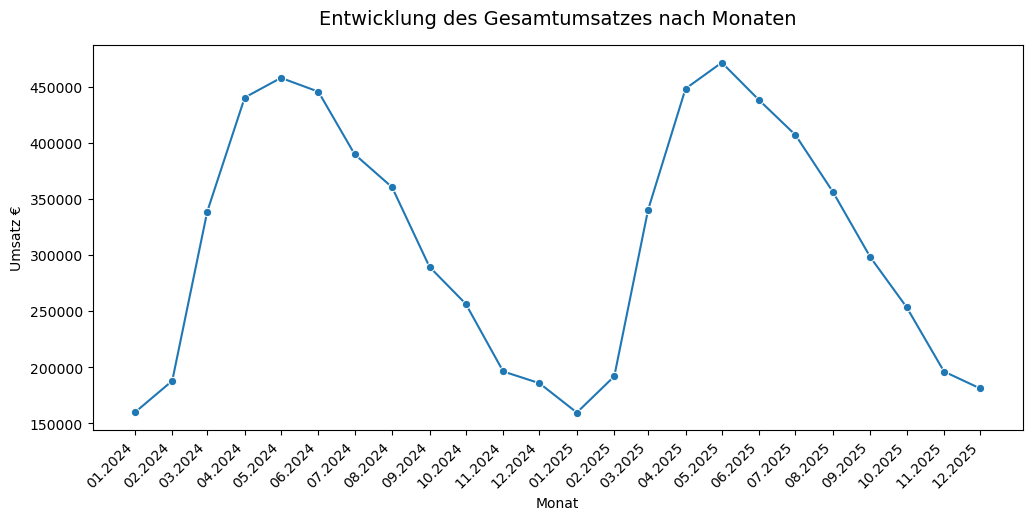

In [28]:
# Importiert die Bibliothek zur Formatierung von Datumsangaben auf den Achsen
import matplotlib.dates as mdates

# Gruppiert den Umsatz nach Monaten für die Trendanalyse
df_trend=df.groupby('monat')['umsatz_eur'].sum().reset_index()

# Setzt die optimale Grafikgröße für die Zeitreihe fest
plt.figure(figsize=(12, 5))

sns.lineplot(data=df_trend,
             x='monat',
             y='umsatz_eur',
             marker='o'
            )

plt.xticks(df_trend['monat'], rotation=45, ha='right')
# Formatiert das Datum auf der X-Achse im Format MM.JJJJ
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m.%Y'))

plt.xlabel('Monat')  
plt.ylabel('Umsatz €')

plt.title('Entwicklung des Gesamtumsatzes nach Monaten', fontsize=14, pad=15)
plt.show()

In beiden betrachteten Jahren ist eine ausgeprägte Saisonalität des Umsatzes erkennbar: Auf einen kräftigen Frühlingsanstieg folgt ein deutlicher Höchststand im Frühsommer (Mai/Juni), dem ein stetiger Rückgang im Herbst bis zum Jahrestief im Januar nachfolgt. Darüber hinaus übertrifft das Umsatzniveau des Jahres 2025 das des Vorjahres leicht, was ungeachtet des gleichen Saisonmusters für ein generelles Wachstum spricht.
Im nächsten Schritt betrachten wir die Saisonalität aufgeschlüsselt nach Produktkategorien.

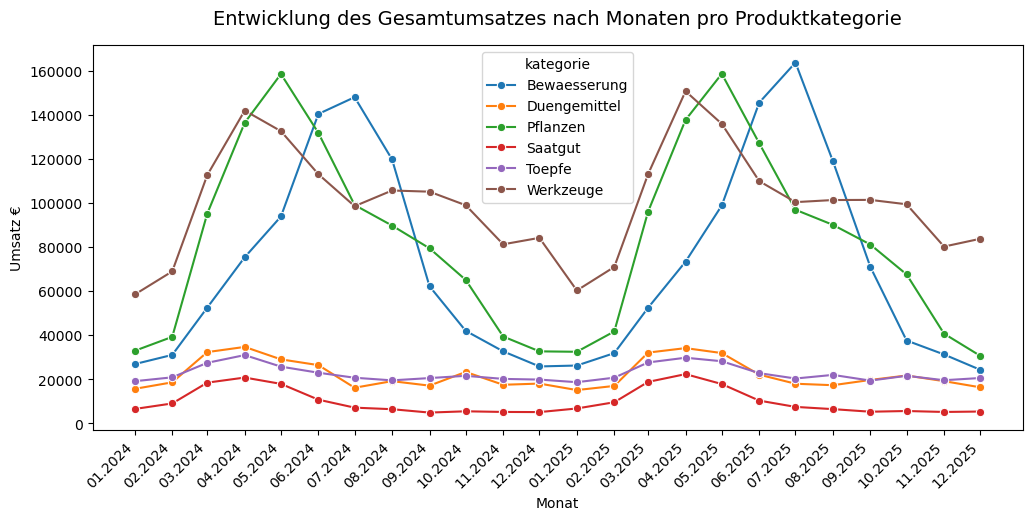

In [29]:
# Gruppiert den Umsatz nach Monaten und Kategorien für die saisonale Analyse
df_trend_seasonal = df.groupby(['monat', 'kategorie'], observed=False)['umsatz_eur'].sum().reset_index()

plt.figure(figsize=(12, 5))

sns.lineplot(data=df_trend_seasonal,
             x='monat',
             y='umsatz_eur',
             hue='kategorie',
             marker='o'
            )

plt.xticks(df_trend['monat'], rotation=45, ha='right')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m.%Y'))

plt.xlabel('Monat')  
plt.ylabel('Umsatz €')

plt.title('Entwicklung des Gesamtumsatzes nach Monaten pro Produktkategorie', fontsize=14, pad=15)
plt.show()

Aus der Abbildung geht klar hervor, dass die saisonalen Schwankungen fast gänzlich von den Hauptkategorien Werkzeuge, Bewässerungssysteme und Pflanzen getrieben werden. Die übrigen Segmente zeigen hingegen einen flachen Verlauf auf niedrigem Niveau.

# 3.1 Korrelationsanalyse der Einflussfaktoren auf den Umsatz (Marketingbudget & Kampagnen)

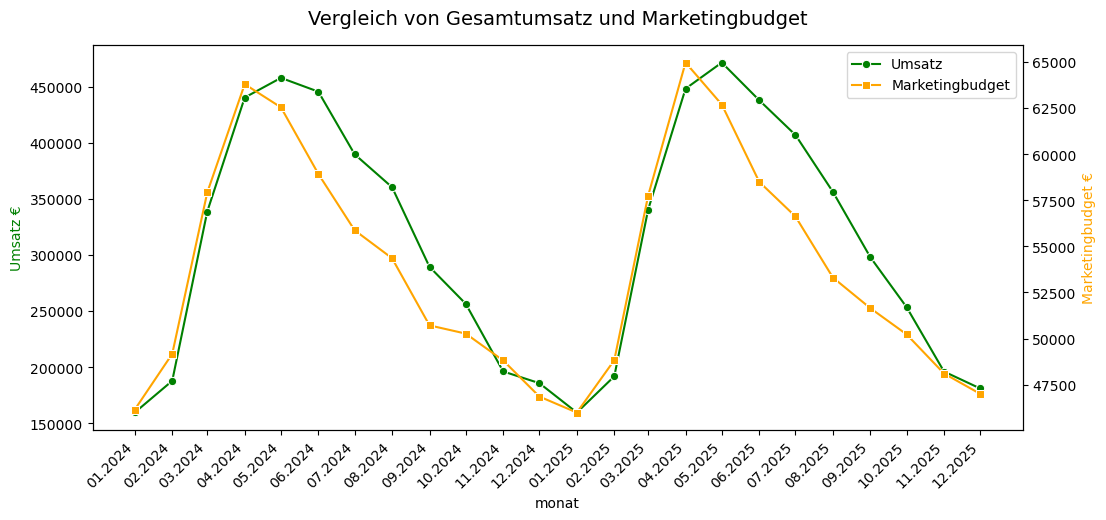

In [30]:
# Gruppiert Umsatz und Marketingbudget monatlich für die Korrelationsanalyse
df_marketing = df.groupby('monat')[['umsatz_eur', 'marketingbudget_eur']].sum().reset_index()

# Basis-Diagramm erstellen und Umsatz (linke Achse) plotten
fig, ax1 = plt.subplots(figsize=(12, 5))
sns.lineplot(data=df_marketing, x='monat', y='umsatz_eur', ax=ax1, color='green', marker='o', label='Umsatz', legend=False)
ax1.set_ylabel('Umsatz €', color='green')

# Zweite Y-Achse spiegeln und Marketingbudget (rechte Achse) plotten
ax2 = ax1.twinx()
sns.lineplot(data=df_marketing, x='monat', y='marketingbudget_eur', ax=ax2, color='orange', marker='s', label='Marketingbudget', legend=False)
ax2.set_ylabel('Marketingbudget €', color='orange')

# Achseneinstellungen und Datumsformatierung anpassen
ax1.set_xticks(df_marketing['monat'])
ax1.set_xticklabels(df_marketing['monat'], rotation=45, ha='right')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m.%Y'))

# Legenden beider Achsen zusammenführen
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.xlabel('Monat')
plt.title('Vergleich von Gesamtumsatz und Marketingbudget', fontsize=14, pad=15)
plt.show()

* **Saisonauftakt (Januar bis März):** Die Umsätze steigen unmittelbar parallel zu den initialen Werbeausgaben.
* **Höchststand:** Während das Marketingbudget im April seinen Höchstwert erreicht, verzeichnet der Umsatz einen Monat später (im Mai) seinen Spitzenwert.
* **Rückläufige Phase:** In den Folgemonaten verringert sich der Umsatz wesentlich träger, als das Budget gekürzt wird.

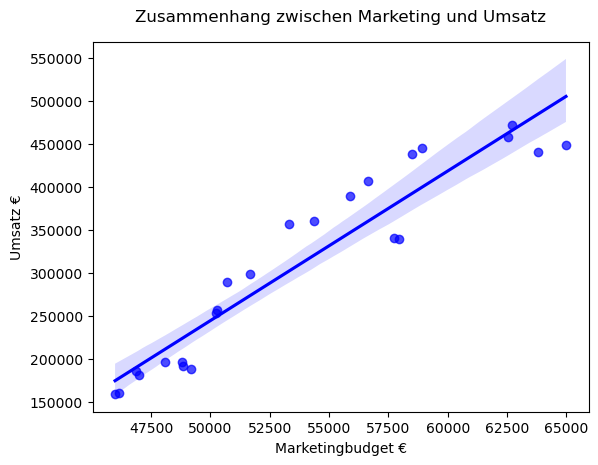

In [31]:
# Scatterplot zur Visualisierung des Zusammenhangs

sns.regplot(data=df_marketing, x='marketingbudget_eur', y='umsatz_eur', color='blue', scatter_kws={'alpha':0.7})

plt.title('Zusammenhang zwischen Marketing und Umsatz', fontsize=12, pad=15)
plt.xlabel('Marketingbudget €')
plt.ylabel('Umsatz €')
plt.show()

Die Visualisierung verdeutlicht einen stark ausgeprägten Zusammenhang zwischen Marketingbudget und Umsatz. Zur mathematischen Absicherung wird ergänzend der Korrelationskoeffizient ermittelt.

In [32]:
# Korrelationskoeffizient berechnen
correlation = df_marketing['umsatz_eur'].corr(df_marketing['marketingbudget_eur'])
print(f"Korrelation: {correlation:.2f}")

Korrelation: 0.95


Der hohe Korrelationskoeffizient ($r = 0,96$) zeigt zwar, dass Budget und Umsatz eng zusammenhängen, beweist aber keinen direkten Werbeeffekt. Logischerweise werden Budgets vor allem für die ohnehin starken Saison-Peaks eingeplant: Das Unternehmen stützt sich dabei auf historische Erfahrungswerte und kann so den Abstand zu Wettbewerbern vergrößern.
Während der Saisoneinstieg zeitlich synchron verläuft, hinken Umsatzspitzen und Abwärtsphasen um einen Monat hinterher. Das Budget zeigt daher eher, wie saisonal geplant wird, und ist kein eigenständiger Treiber für den Umsatz.

### Fazit: Korrelation zwischen Marketingbudget und Umsatz

Die Analyse zeigt einen starken Zusammenhang zwischen Werbeausgaben und Umsatz ($r = 0,96$): Der Saisonauftakt von Januar bis März verläuft absolut synchron, während der Umsatzhöchststand im Mai und die Abwärtsphase jeweils um einen Monat hinter dem Budget hinterherhinken.

Das belegt jedoch keinen direkten Werbeeffekt. Vielmehr stützt sich das Unternehmen auf historische Erfahrungswerte, um Budgets gezielt für die starken Saison-Peaks einzuplanen und den Abstand zum Wettbewerb auszubauen. Da sich Umsätze in der Rücklaufphase zudem deutlich träger entwickeln als die Budgetkürzungen, fungiert das Budget als Spiegelbild der Saisongestaltung und nicht als eigenständiger Treiber für den Umsatz.